# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Jordan Sebastian Simatupang| 5054251038|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [53]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import auc, roc_curve

In [54]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
data = pd.read_csv('diabetes.csv')
print(data.info())
print(data.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB
None
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcom

<Axes: xlabel='Outcome'>

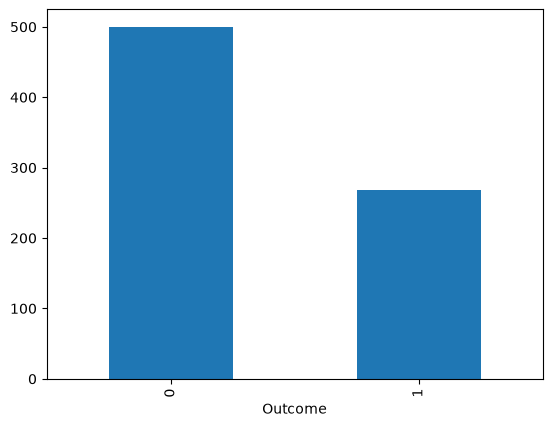

In [55]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
data['Outcome'].value_counts().plot(kind='bar')

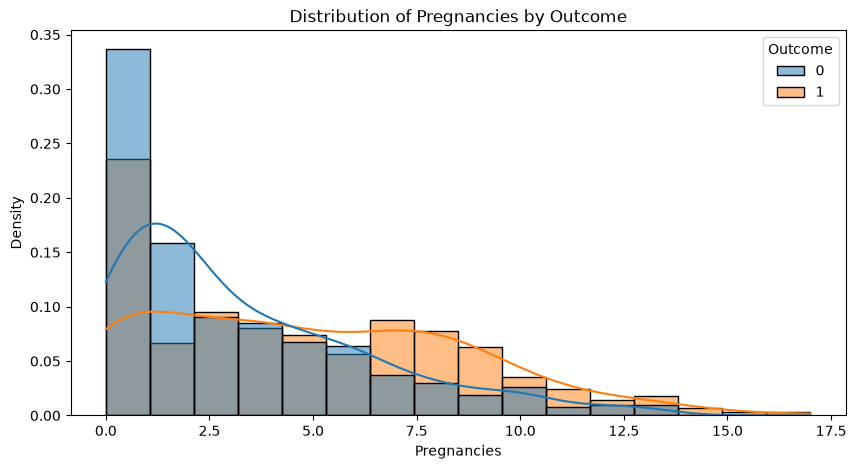

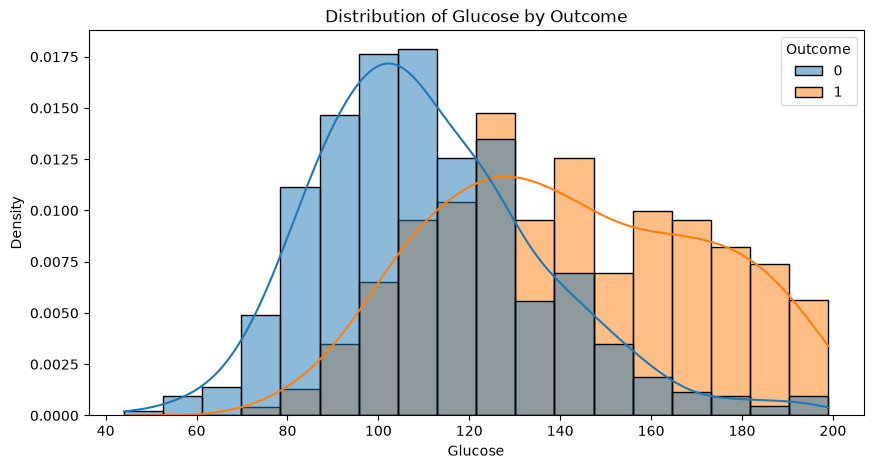

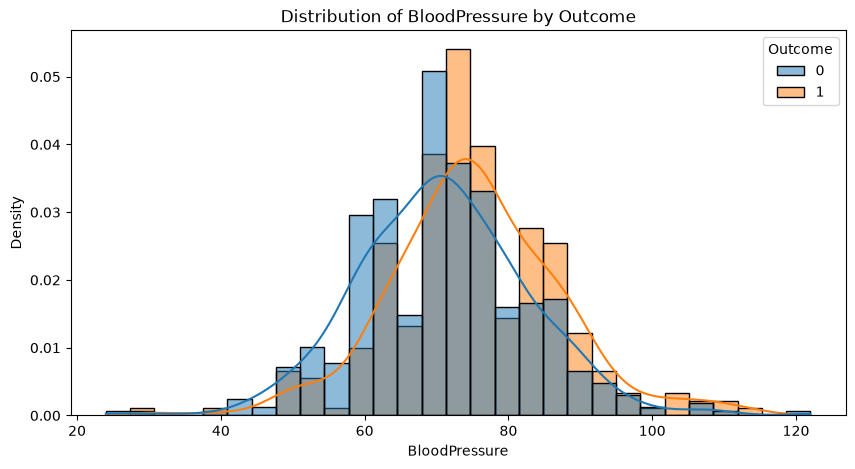

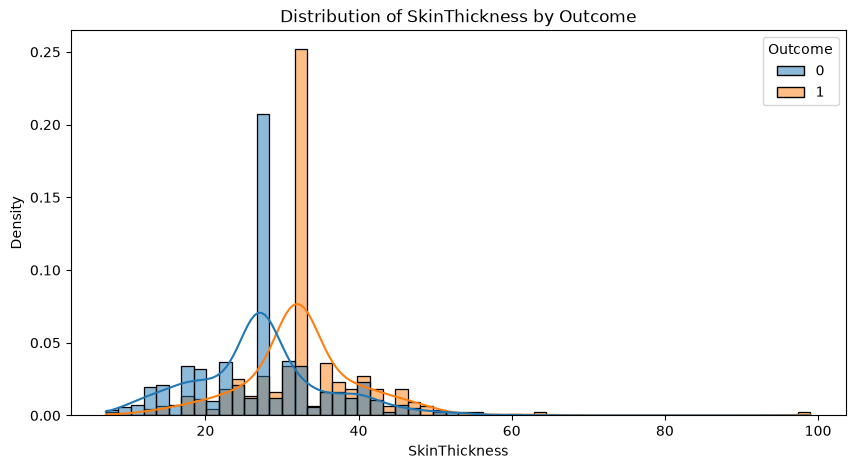

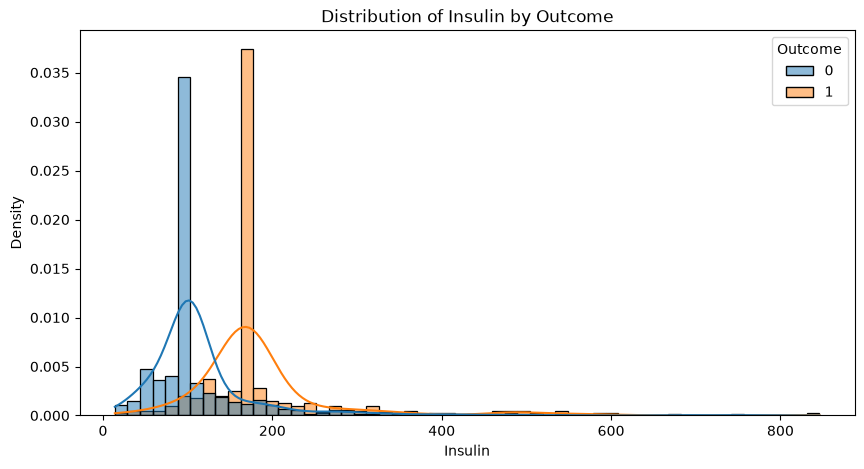

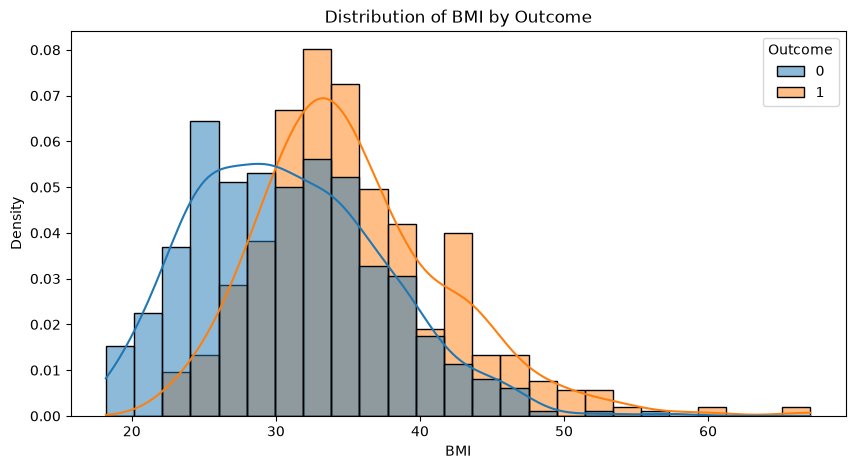

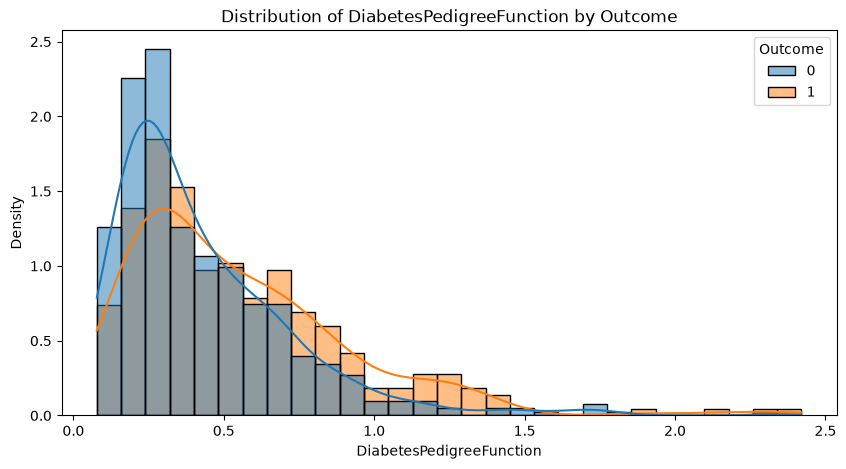

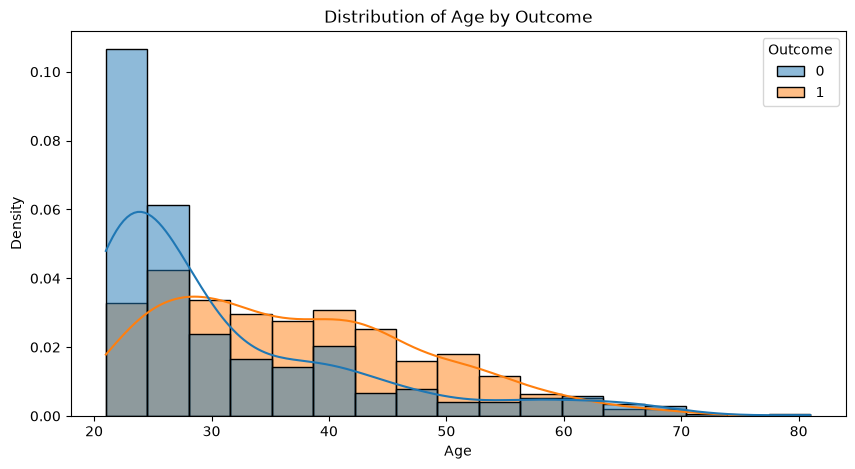

In [56]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.
for column in data.columns[:-1]:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=data, x=column, hue='Outcome', kde=True, stat="density", common_norm=False)
    plt.title(f'Distribution of {column} by Outcome')
    plt.show()

<Axes: >

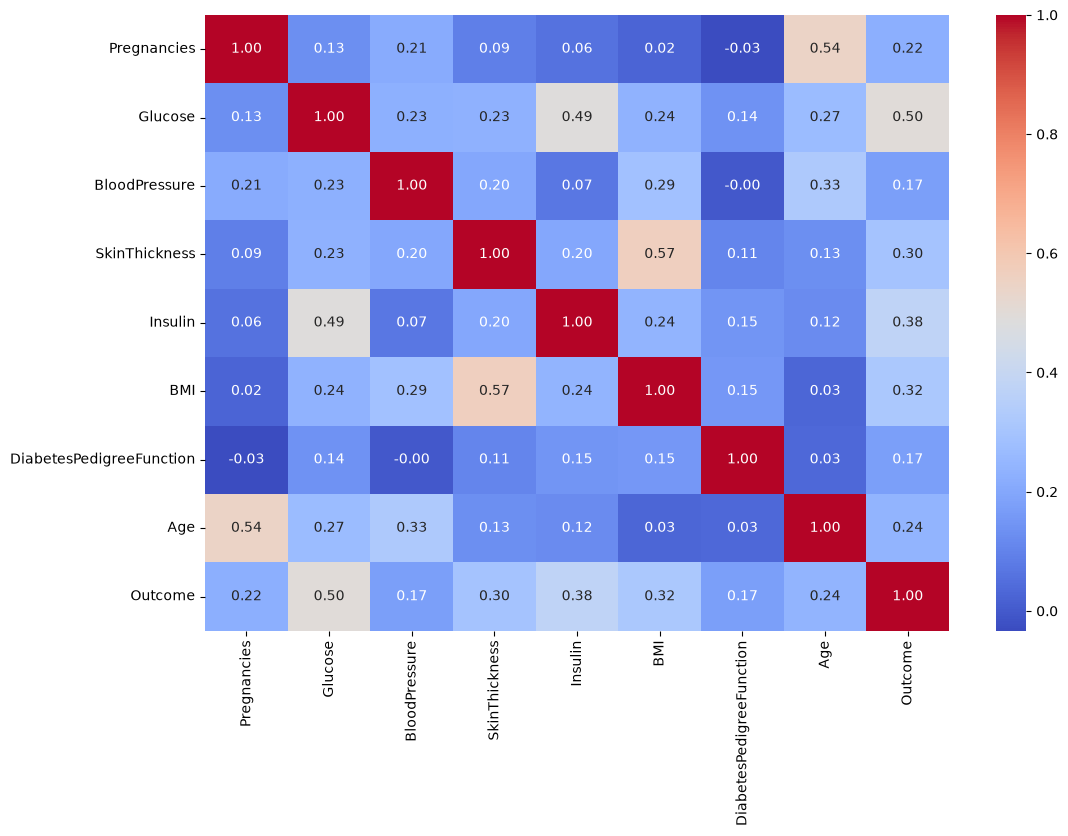

In [57]:
# Tampilkan heatmap korelasi antar fitur.
korelasi = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f")

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [58]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.
nilai_nol = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for kolom in nilai_nol:
    jumlah_nol = (data[kolom] == 0).sum()
    print(f'Jumlah nilai 0 pada kolom {kolom}: {jumlah_nol}')

Jumlah nilai 0 pada kolom Glucose: 0
Jumlah nilai 0 pada kolom BloodPressure: 0
Jumlah nilai 0 pada kolom SkinThickness: 0
Jumlah nilai 0 pada kolom Insulin: 0
Jumlah nilai 0 pada kolom BMI: 0


In [59]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
data[nilai_nol] = data[nilai_nol].replace(0, np.nan)
imputer = SimpleImputer(strategy="median")
data[nilai_nol] = imputer.fit_transform(data[nilai_nol])

In [60]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
x = data.drop('Outcome', axis=1)
y = data['Outcome']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print(f'Jumlah data train: {x_train.shape[0]}, Jumlah data test: {x_test.shape[0]}')

Jumlah data train: 614, Jumlah data test: 154


In [61]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [62]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
def train_gaussian_nb(x_train_scaled, y_train):
    model = GaussianNB()
    model.fit(x_train_scaled, y_train)
    return model

train_gaussian_nb(x_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[400.,214.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.65,0.35]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 8)","[[-0.15,-0.38,-0.14,...,-0.24,-0.12,-0.18], [ 0.28, 0.71, 0.26,..., 0.45, 0.23, 0.33]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 8)","[[0.81,0.61,0.98,...,0.86,0.85,0.96], [1.23,0.97,0.94,...,0.94,1.2 ,0.91]]"


In [63]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
model = GaussianNB()
model.fit(x_train_scaled, y_train)
prediksi_gnb = model.predict(x_test_scaled)
probabilitas_gnb = model.predict_proba(x_test_scaled)[:, 1]

## 3.2 Logistic Regression

In [64]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
def train_logistic_regression(x_train_scaled, y_train):
    model = LogisticRegression()
    model.fit(x_train_scaled, y_train)
    return model

train_logistic_regression(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [65]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
model_lr = LogisticRegression()
model_lr.fit(x_train_scaled, y_train)
prediksi_lr = model_lr.predict(x_test_scaled)
probabilitas_lr = model_lr.predict_proba(x_test_scaled)[:, 1]

# 4. Evaluasi Model

In [66]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
evaluasi_gnb = {
    'Accuracy': accuracy_score(y_test, prediksi_gnb),
    'Precision': precision_score(y_test, prediksi_gnb),
    'Recall': recall_score(y_test, prediksi_gnb),
    'F1-Score': f1_score(y_test, prediksi_gnb)
}
evaluasi_lr = {
    'Accuracy': accuracy_score(y_test, prediksi_lr),
    'Precision': precision_score(y_test, prediksi_lr),
    'Recall': recall_score(y_test, prediksi_lr),
    'F1-Score': f1_score(y_test, prediksi_lr)
}
table_evaluasi = pd.DataFrame([evaluasi_gnb, evaluasi_lr], index=['GaussianNB', 'LogisticRegression'])
print(table_evaluasi)

                    Accuracy  Precision    Recall  F1-Score
GaussianNB          0.727273   0.603448  0.648148  0.625000
LogisticRegression  0.707792   0.588235  0.555556  0.571429


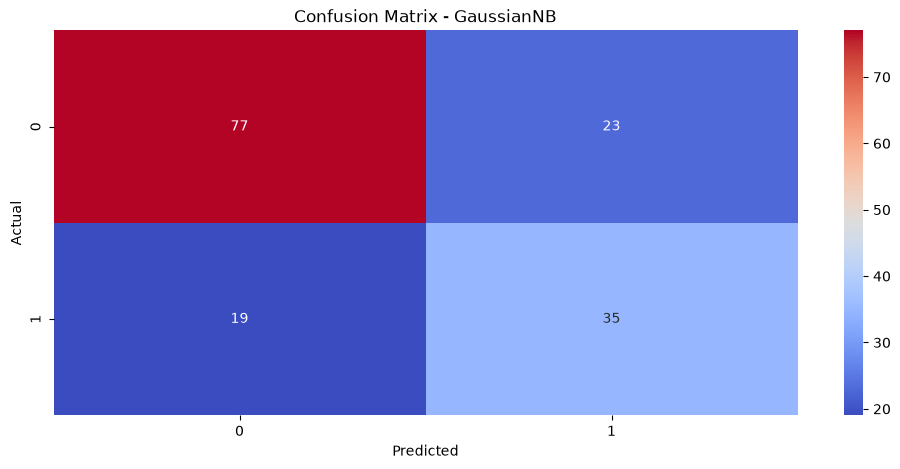

In [67]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
CM_gnb = pd.crosstab(y_test, prediksi_gnb, rownames=['Actual'], colnames=['Predicted'])
CM_lr = pd.crosstab(y_test, prediksi_lr, rownames=['Actual'], colnames=['Predicted'])
plt.figure(figsize=(12, 5))
sns.heatmap(CM_gnb, annot=True, fmt='d', cmap='coolwarm')
plt.title('Confusion Matrix - GaussianNB')
plt.show()

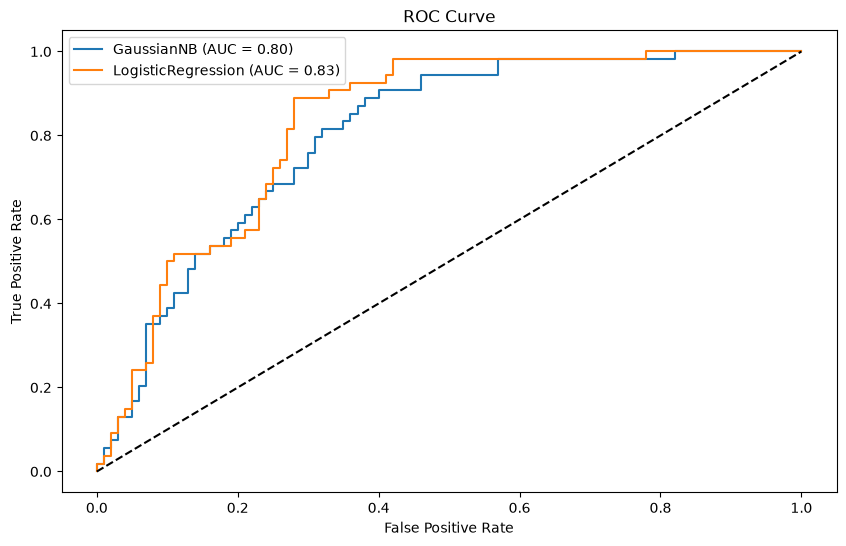

In [68]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
ROC_gnb = roc_curve(y_test, probabilitas_gnb)
ROC_lr = roc_curve(y_test, probabilitas_lr)
AUC_gnb = auc(ROC_gnb[0], ROC_gnb[1])
AUC_lr = auc(ROC_lr[0], ROC_lr[1])
plt.figure(figsize=(10, 6))
plt.plot(ROC_gnb[0], ROC_gnb[1], label=f'GaussianNB (AUC = {AUC_gnb:.2f})')
plt.plot(ROC_lr[0], ROC_lr[1], label=f'LogisticRegression (AUC = {AUC_lr:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

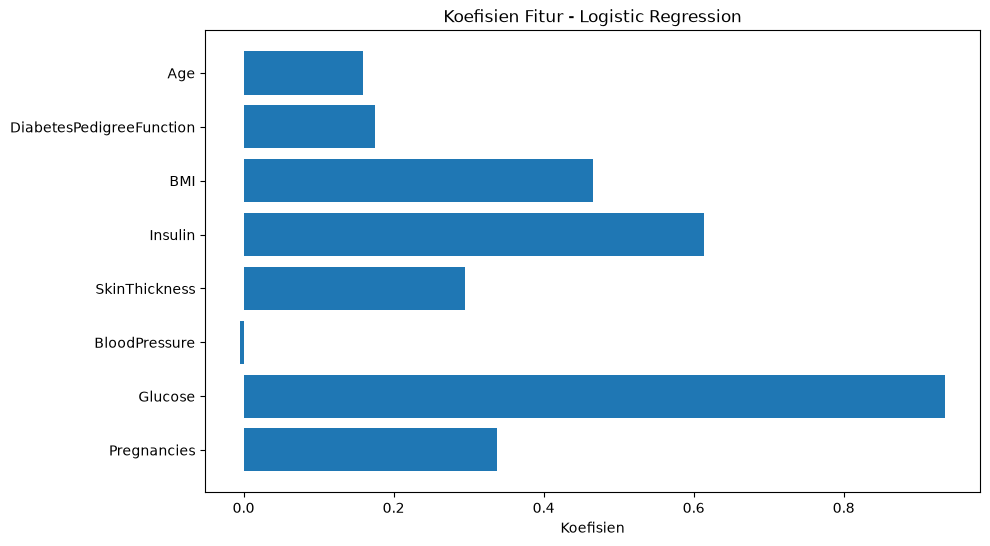

In [69]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.
koefisien = model_lr.coef_[0]
plt.figure(figsize=(10, 6))
plt.barh(x.columns, koefisien)
plt.xlabel('Koefisien')
plt.title('Koefisien Fitur - Logistic Regression')
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Gaussian Naive Bayes dan Logistic Regression berdasarkan hasil evaluasi. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

Hasil evaluasi menunjukkan bahwa GaussianNB memiliki performa sedikit lebih baik daripada Logistic Regression pada sebagian besar metrik. GaussianNB memperoleh accuracy 72,73%, precision 60,34%, recall 64,81%, dan F1-score 62,50%. Logistic Regression memperoleh accuracy 70,78%, precision 58,82%, recall 55,56%, dan F1-score 57,14%.

Pada confusion matrix GaussianNB, terdapat 77 data kelas 0 yang diprediksi benar dan 35 data kelas 1 yang diprediksi benar. Model juga menghasilkan 23 false positive dan 19 false negative. Jadi, masih ada data pasien diabetes yang diprediksi tidak diabetes. Recall GaussianNB yang lebih tinggi menunjukkan bahwa model ini lebih baik dalam menemukan pasien yang memiliki diabetes pada eksperimen ini.

Walaupun metrik klasifikasi GaussianNB lebih tinggi, Logistic Regression memiliki AUC 0,83, sedangkan GaussianNB memiliki AUC 0,80. Ini berarti Logistic Regression sedikit lebih baik dalam membedakan kelas pada berbagai threshold probabilitas. Namun, pada threshold default yang digunakan, GaussianNB memberikan hasil prediksi label yang lebih baik.

GaussianNB mengasumsikan bahwa fitur numerik pada setiap kelas mengikuti distribusi Gaussian dan setiap fitur saling independen. Logistic Regression menggunakan hubungan linear antara fitur dan probabilitas diabetes. Data sudah melalui imputasi median dan standardisasi, sehingga kedua model dapat dilatih dengan data yang lebih konsisten.

Koefisien Logistic Regression menunjukkan bahwa Glucose memiliki pengaruh positif paling besar terhadap prediksi diabetes. BMI, Pregnancies, SkinThickness, DiabetesPedigreeFunction, dan Age juga memiliki pengaruh positif, sedangkan BloodPressure memiliki pengaruh yang sangat kecil. Hasil ini membantu menjelaskan fitur mana yang paling berhubungan dengan prediksi diabetes.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

#### Kesimpulan

1. GaussianNB memberikan hasil klasifikasi lebih baik pada threshold default, dengan accuracy 72,73% dan F1-score 62,50%.
2. Logistic Regression memperoleh accuracy 70,78% dan F1-score 57,14%, sehingga hasilnya sedikit lebih rendah daripada GaussianNB.
3. GaussianNB memiliki recall lebih tinggi, yaitu 64,81%. Model ini lebih baik dalam menemukan pasien yang benar-benar diabetes.
4. Logistic Regression memiliki AUC lebih tinggi, yaitu 0,83 dibandingkan GaussianNB sebesar 0,80. Artinya, Logistic Regression sedikit lebih baik dalam membedakan kelas pada berbagai threshold.
5. Glucose menjadi fitur yang paling kuat memengaruhi prediksi Logistic Regression.

#### Saran

1. Gunakan validasi silang agar hasil evaluasi lebih stabil.
2. Uji beberapa nilai threshold untuk meningkatkan recall pasien diabetes.
3. Atur parameter model, misalnya `C` pada Logistic Regression dan `var_smoothing` pada GaussianNB.
4. Gunakan `classification_report` dan confusion matrix untuk mengevaluasi kesalahan tiap kelas dengan lebih lengkap.
5. Bandingkan kedua model dengan model lain seperti Random Forest, SVM, atau K-Nearest Neighbors.